In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
import scipy.cluster.hierarchy as shc
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from tqdm import tqdm
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorboardX import SummaryWriter
import os
import time
from torcheval.metrics import R2Score
from sklearn.metrics import r2_score
import shap
import pickle
from sklearn.linear_model import LinearRegression
from scipy import stats
from decimal import Decimal
import seaborn as sns
import warnings


warnings.filterwarnings("ignore")

%matplotlib inline
pd.set_option('display.max_columns', None)

# load model and data

In [60]:
model_path = 'results/linear_factor_v1/linear_model_0.pkl'
with open(model_path, 'rb') as f:
    model_factor_0 = pickle.load(f)

model_path = 'results/linear_factor_v1/linear_model_1.pkl'
with open(model_path, 'rb') as f:
    model_factor_1 = pickle.load(f)

model_path = 'results/linear_factor_v1/linear_model_2.pkl'
with open(model_path, 'rb') as f:
    model_factor_2 = pickle.load(f)

model_path = 'results/linear_factor_v1/linear_model_3.pkl'
with open(model_path, 'rb') as f:
    model_factor_3 = pickle.load(f)

model_path = 'results/linear_factor_v1/linear_model_4.pkl'
with open(model_path, 'rb') as f:
    model_factor_4 = pickle.load(f)


In [7]:
df_total = pd.read_csv('../data/deep_factor_test_retest_imputed_all_standardized.csv')
df_num = df_total.iloc[:, 2:]
df_X = df_num.iloc[:, :12]
df_y_total = df_num.iloc[:, 12:]

In [ ]:
sns.set(style = 'whitegrid')   
tip = sns.load_dataset("tips")   
plt.figure(figsize=(10, 5))       
sns.stripplot(x="value", y="variable", data=df_X.melt(), jitter=False) 

# plot coeffs

Text(0.5, 1.0, 'coefficients of factor 4')

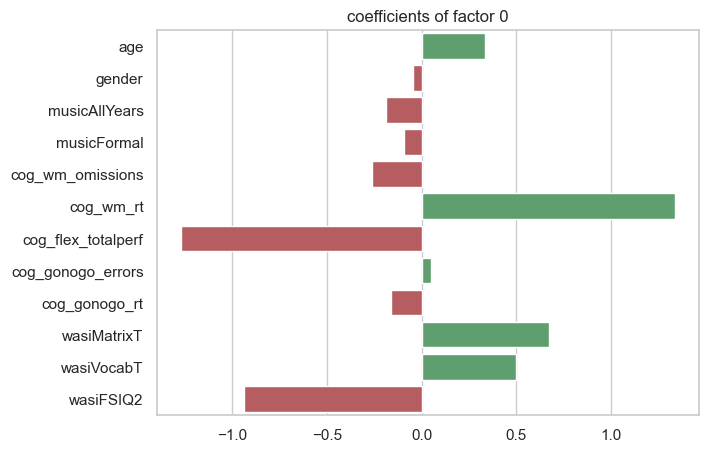

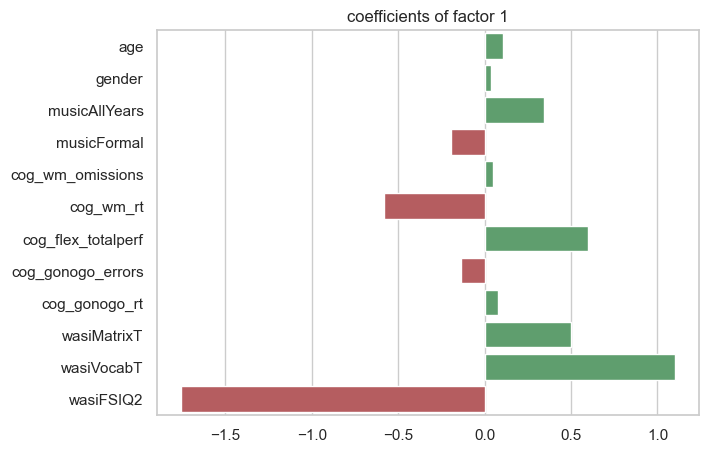

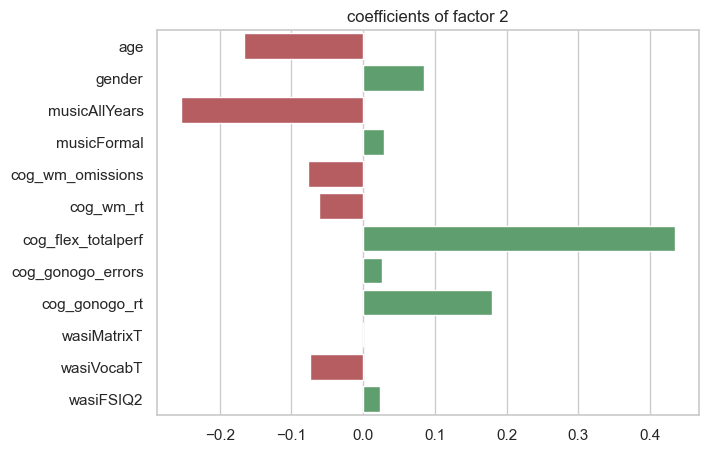

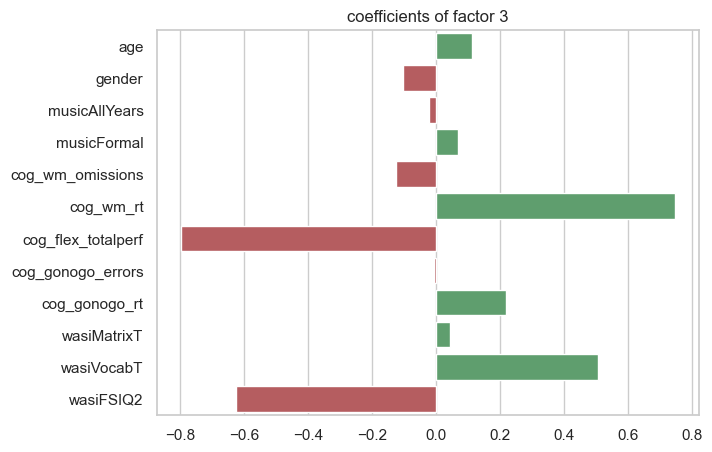

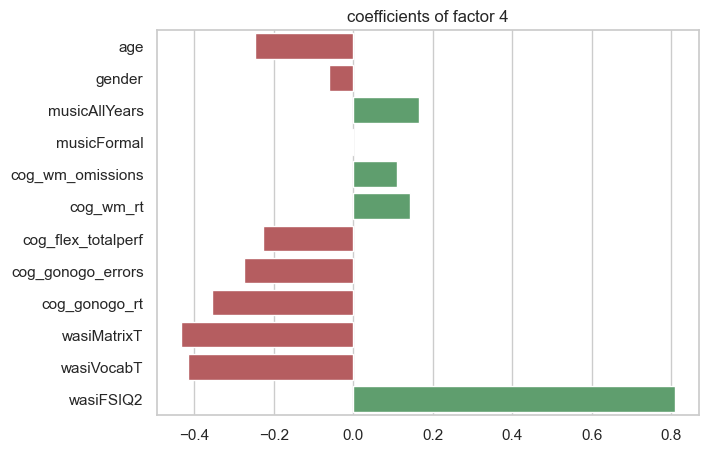

In [66]:
plt.figure(figsize=(7, 5))
color = ['g' if i > 0 else 'r' for i in model_factor_0.coef_]
sns.barplot(y=df_X.columns, x=model_factor_0.coef_, palette=color).set_title('coefficients of factor 0')

plt.figure(figsize=(7, 5))
color = ['g' if i > 0 else 'r' for i in model_factor_1.coef_]
sns.barplot(y=df_X.columns, x=model_factor_1.coef_, palette=color).set_title('coefficients of factor 1')

plt.figure(figsize=(7, 5))
color = ['g' if i > 0 else 'r' for i in model_factor_2.coef_]
sns.barplot(y=df_X.columns, x=model_factor_2.coef_, palette=color).set_title('coefficients of factor 2')

plt.figure(figsize=(7, 5))
color = ['g' if i > 0 else 'r' for i in model_factor_3.coef_]
sns.barplot(y=df_X.columns, x=model_factor_3.coef_, palette=color).set_title('coefficients of factor 3')

plt.figure(figsize=(7, 5))
color = ['g' if i > 0 else 'r' for i in model_factor_4.coef_]
sns.barplot(y=df_X.columns, x=model_factor_4.coef_, palette=color).set_title('coefficients of factor 4')

In [71]:
#

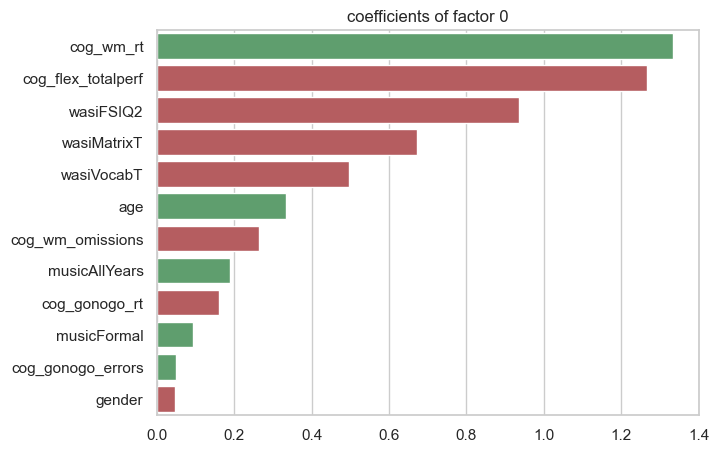

In [74]:
plt.figure(figsize=(7, 5))
color = ['g' if i > 0 else 'r' for i in model_factor_0.coef_]
g = sns.barplot(y=df_X.columns, 
                x=np.abs(model_factor_0.coef_), 
                palette=color,
                order=df_X.columns[np.argsort(-np.abs(model_factor_0.coef_))]
               )
g.set_title('coefficients of factor 0')
name = 'abs_coef_lr_factor0'
g.figure.savefig("results/" + name + ".png") 

Text(0.5, 1.0, 'mean abs shap values of LR for factor 0')

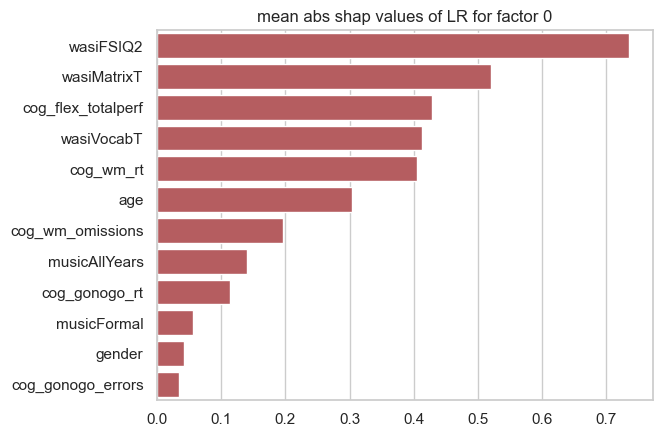

In [92]:
#shap
explainer = shap.Explainer(model_factor_0.predict, df_X)
shap_values = explainer(df_X)
mean_val = np.mean(np.abs(shap_values.values), axis=0)
g = sns.barplot(y=df_X.columns,
                x=mean_val, palette=['r'],
                order=df_X.columns[np.argsort(-mean_val)]
               )
g.set_title('mean abs shap values of LR for factor 0')

# name = 'mean_abs_shap_fac4'
# g.figure.savefig("results/" + name + ".png") 

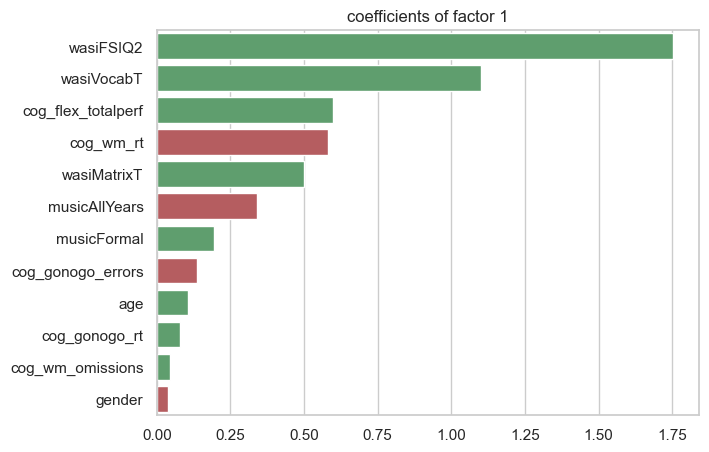

In [75]:
plt.figure(figsize=(7, 5))
color = ['g' if i > 0 else 'r' for i in model_factor_1.coef_]
g = sns.barplot(y=df_X.columns, 
                x=np.abs(model_factor_1.coef_), 
                palette=color,
                order=df_X.columns[np.argsort(-np.abs(model_factor_1.coef_))]
               )
g.set_title('coefficients of factor 1')
name = 'abs_coef_lr_factor1'
g.figure.savefig("results/" + name + ".png") 

Text(0.5, 1.0, 'mean abs shap values of LR for factor 1')

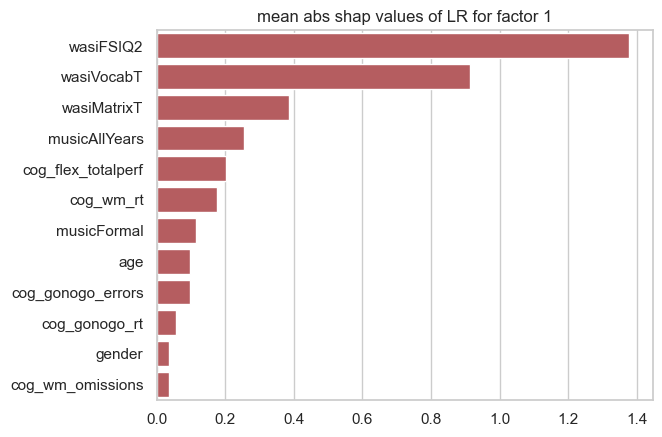

In [91]:
#shap
explainer = shap.Explainer(model_factor_1.predict, df_X)
shap_values = explainer(df_X)
mean_val = np.mean(np.abs(shap_values.values), axis=0)
g = sns.barplot(y=df_X.columns,
                x=mean_val, palette=['r'],
                order=df_X.columns[np.argsort(-mean_val)]
               )
g.set_title('mean abs shap values of LR for factor 1')

# name = 'mean_abs_shap_fac4'
# g.figure.savefig("results/" + name + ".png") 

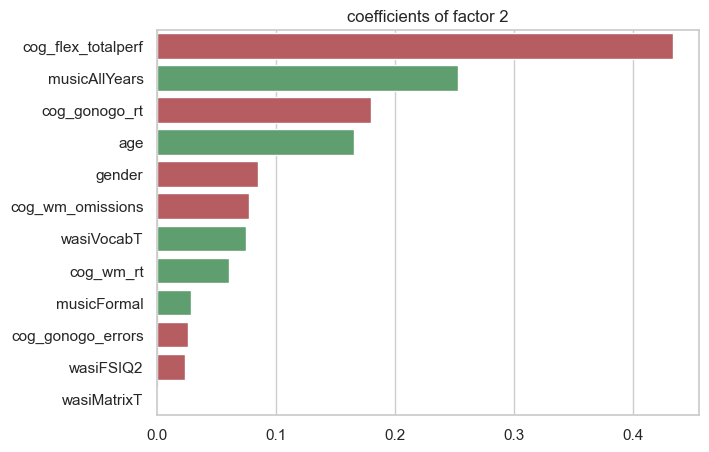

In [76]:
plt.figure(figsize=(7, 5))
color = ['g' if i > 0 else 'r' for i in model_factor_2.coef_]
g = sns.barplot(y=df_X.columns, 
                x=np.abs(model_factor_2.coef_), 
                palette=color,
                order=df_X.columns[np.argsort(-np.abs(model_factor_2.coef_))]
               )
g.set_title('coefficients of factor 2')
name = 'abs_coef_lr_factor2'
g.figure.savefig("results/" + name + ".png") 

# plt.figure(figsize=(7, 5))
# color = ['g' if i > 0 else 'r' for i in model_factor_2.coef_]
# sns.barplot(y=df_X.columns, x=model_factor_2.coef_, palette=color).set_title('coefficients of factor 2')

Text(0.5, 1.0, 'mean abs shap values of LR for factor 2')

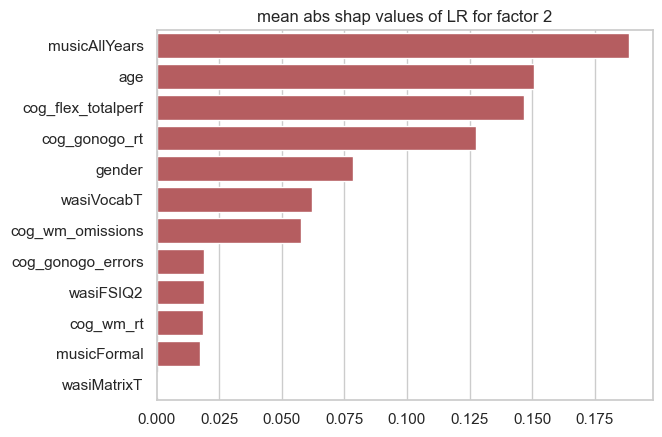

In [90]:
#shap
explainer = shap.Explainer(model_factor_2.predict, df_X)
shap_values = explainer(df_X)
mean_val = np.mean(np.abs(shap_values.values), axis=0)
g = sns.barplot(y=df_X.columns,
                x=mean_val, palette=['r'],
                order=df_X.columns[np.argsort(-mean_val)]
               )
g.set_title('mean abs shap values of LR for factor 2')

# name = 'mean_abs_shap_fac4'
# g.figure.savefig("results/" + name + ".png") 

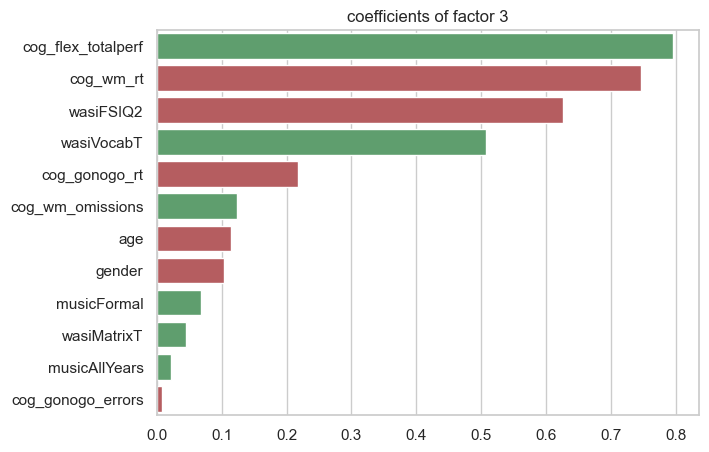

In [77]:
plt.figure(figsize=(7, 5))
color = ['g' if i > 0 else 'r' for i in model_factor_3.coef_]
g = sns.barplot(y=df_X.columns, 
                x=np.abs(model_factor_3.coef_), 
                palette=color,
                order=df_X.columns[np.argsort(-np.abs(model_factor_3.coef_))]
               )
g.set_title('coefficients of factor 3')
name = 'abs_coef_lr_factor3'
g.figure.savefig("results/" + name + ".png") 


# plt.figure(figsize=(7, 5))
# color = ['g' if i > 0 else 'r' for i in model_factor_3.coef_]
# sns.barplot(y=df_X.columns, x=model_factor_3.coef_, palette=color).set_title('coefficients of factor 3')

Text(0.5, 1.0, 'mean abs shap values of LR for factor 3')

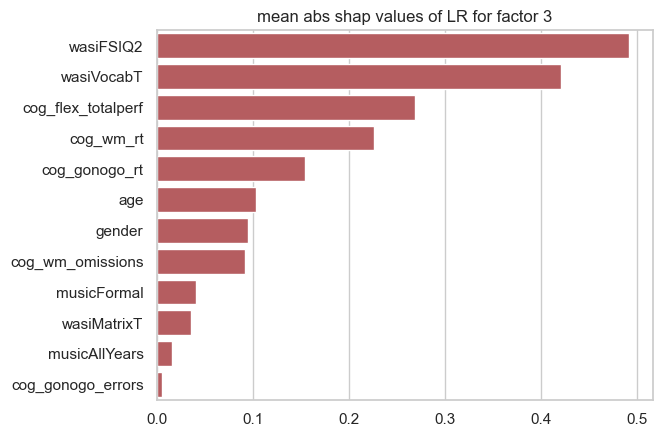

In [89]:
#shap
explainer = shap.Explainer(model_factor_3.predict, df_X)
shap_values = explainer(df_X)
mean_val = np.mean(np.abs(shap_values.values), axis=0)
g = sns.barplot(y=df_X.columns,
                x=mean_val, palette=['r'],
                order=df_X.columns[np.argsort(-mean_val)]
               )
g.set_title('mean abs shap values of LR for factor 3')

# name = 'mean_abs_shap_fac4'
# g.figure.savefig("results/" + name + ".png") 

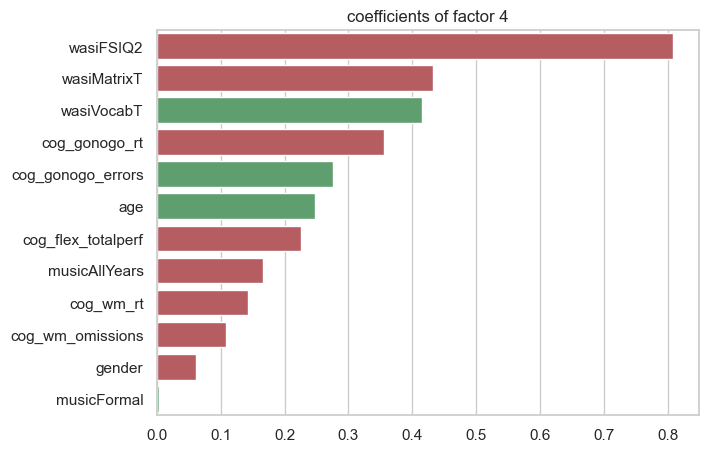

In [78]:
plt.figure(figsize=(7, 5))
color = ['g' if i > 0 else 'r' for i in model_factor_4.coef_]
g = sns.barplot(y=df_X.columns, 
                x=np.abs(model_factor_4.coef_), 
                palette=color,
                order=df_X.columns[np.argsort(-np.abs(model_factor_4.coef_))]
               )
g.set_title('coefficients of factor 4')
name = 'abs_coef_lr_factor4'
g.figure.savefig("results/" + name + ".png") 

# plt.figure(figsize=(7, 5))
# color = ['g' if i > 0 else 'r' for i in model_factor_4.coef_]
# sns.barplot(y=df_X.columns, x=model_factor_4.coef_, palette=color).set_title('coefficients of factor 4')

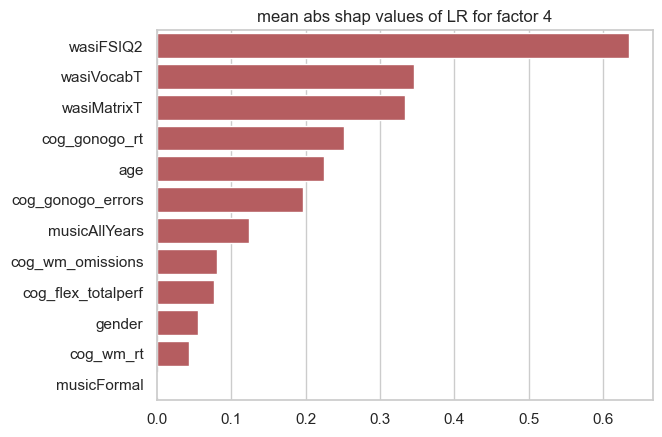

In [88]:
#shap
explainer = shap.Explainer(model_factor_4.predict, df_X)
shap_values = explainer(df_X)
mean_val = np.mean(np.abs(shap_values.values), axis=0)
g = sns.barplot(y=df_X.columns,
                x=mean_val, palette=['r'],
                order=df_X.columns[np.argsort(-mean_val)]
               )
g.set_title('mean abs shap values of LR for factor 4')

name = 'mean_abs_shap_fac4'
# g.figure.savefig("results/" + name + ".png") 